In [1]:
import xarray as xr
import pandas as pd
import numpy as np

import zarr
import numcodecs

import glob
import os
import re

# Plotting stuff:
import matplotlib.pyplot as plt
from matplotlib import colormaps
import matplotlib.colors as mcolors
from matplotlib.colors import LinearSegmentedColormap, TwoSlopeNorm
import matplotlib.cm as cm
import cartopy.crs as ccrs
import cartopy.feature as cft
import cmocean as cmo
import matplotlib as mpl
import matplotlib.ticker as mticker

import psutil
import dask
from dask.distributed import Client

In [2]:
def setup_dask_client(
    workload_type="io",        # "cpu", "io", or "mixed"
    max_workers=None,           # Limit max workers (default = all cores)
    reserve_mem_gb=50,          # Memory reserved for system and overhead
    max_mem_gb=None,            # Cap usable memory if needed
    dashboard=True
):
    """
    Setup Dask client with auto-scaling for workload type.

    Parameters:
        workload_type (str): Type of workload - "cpu", "io", or "mixed"
        max_workers (int): Max logical cores to use (default = system max)
        reserve_mem_gb (int): System memory to reserve
        max_mem_gb (int): Cap memory usage (defaults to system memory)
        dashboard (bool): Whether to print the dashboard link

    Returns:
        dask.distributed.Client
    """
    assert workload_type in ("cpu", "io", "mixed"), "Invalid workload_type"

    logical_cores = psutil.cpu_count(logical=True)
    total_memory_gb = psutil.virtual_memory().total / 1e9

    if max_workers is None:
        max_workers = logical_cores

    if max_mem_gb is None:
        max_mem_gb = total_memory_gb

    usable_mem_gb = max_mem_gb - reserve_mem_gb

    # Recommended presets based on workload type
    if workload_type == "cpu":
        threads_per_worker = 1
        n_workers = min(max_workers, logical_cores)
    elif workload_type == "io":
        threads_per_worker = 8
        n_workers = max(1, logical_cores // threads_per_worker)
    else:  # "mixed"
        threads_per_worker = 4
        n_workers = max(1, logical_cores // threads_per_worker)

    memory_per_worker = usable_mem_gb // n_workers

    client = Client(
        n_workers=n_workers,
        threads_per_worker=threads_per_worker,
        memory_limit=f"{int(memory_per_worker)}GB"
    )

    if dashboard:
        print(f"Dask dashboard: {client.dashboard_link}")

    return client

In [3]:
client = setup_dask_client(workload_type="io")
client

Dask dashboard: /proxy/8787/status


Connection method: Cluster object,Cluster type: distributed.LocalCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 12
Total threads: 96,Total memory: 134.11 GiB
Status: running,Using processes: True
Comm: tcp://127.0.0.1:45557,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B
Comm: tcp://127.0.0.1:37213,Total threads: 8
Dashboard: /proxy/44001/status,Memory: 11.18 GiB
Nanny: tcp://127.0.0.1:43633,


# Open data

Because of the way zarr is stored we don't need to worry about preprocessing it. We can open the whole store lazily and then select the data we want.

This zarr store has also been chunked in an efficient way: (time: 20, lat: 1666, lon: 2271), so there's no need to specify chunking when opening. If you need it to be chunked differently thenm do it after it has been opend, i.e. ds_z.chunk({'time': -1, 'lat': 1, 'lon': 1})

In [4]:
ds_z = xr.open_zarr("/g/data/su28/himawari-ahi/cloud/ct/aus_regional_domain/S_NWC_CT_HIMA08_HIMA-N-NR.zarr", consolidated=True)

In [8]:
ds_z.lat

<xarray.DataArray 'lat' (lat: 1666)> Size: 13kB
array([ 19.37467 ,  19.324055,  19.273439, ..., -64.799116, -64.849731,
       -64.900347])
Coordinates:
  * lat      (lat) float64 13kB 19.37 19.32 19.27 19.22 ... -64.8 -64.85 -64.9
Attributes:
    axis:           Y
    long_name:      latitude
    standard_name:  latitude
    units:          degrees_north

# Plotting

Now we are going to plot some of the cloud data.

First let's create a dictionary of all the cloud types. This info is an attribute in the `ct` variable.

In [6]:
comment = '1:  Cloud-free land; 2:  Cloud-free sea; 3:  Snow over land;  4:  Sea ice; 5:  Very low clouds; 6:  Low clouds; 7:  Mid-level clouds;  8:  High opaque clouds; 9:  Very high opaque clouds;  10:  Fractional clouds; 11:  High semitransparent thin clouds;  12:  High semitransparent moderately thick clouds;  13:  High semitransparent thick clouds;  14:  High semitransparent above low or medium clouds;  15:  High semitransparent above snow/ice'

# Use regex to extract values and labels
matches = re.findall(r'(\d+):\s+([^;]+)', comment)

# Convert to dictionary
category_dict = {int(num): desc.strip() for num, desc in matches}

# Print result
for k, v in sorted(category_dict.items())[:14]:
    print(f"{k}: {v}")

1: Cloud-free land
2: Cloud-free sea
3: Snow over land
4: Sea ice
5: Very low clouds
6: Low clouds
7: Mid-level clouds
8: High opaque clouds
9: Very high opaque clouds
10: Fractional clouds
11: High semitransparent thin clouds
12: High semitransparent moderately thick clouds
13: High semitransparent thick clouds
14: High semitransparent above low or medium clouds


Now let's plot the 1 timestamp.

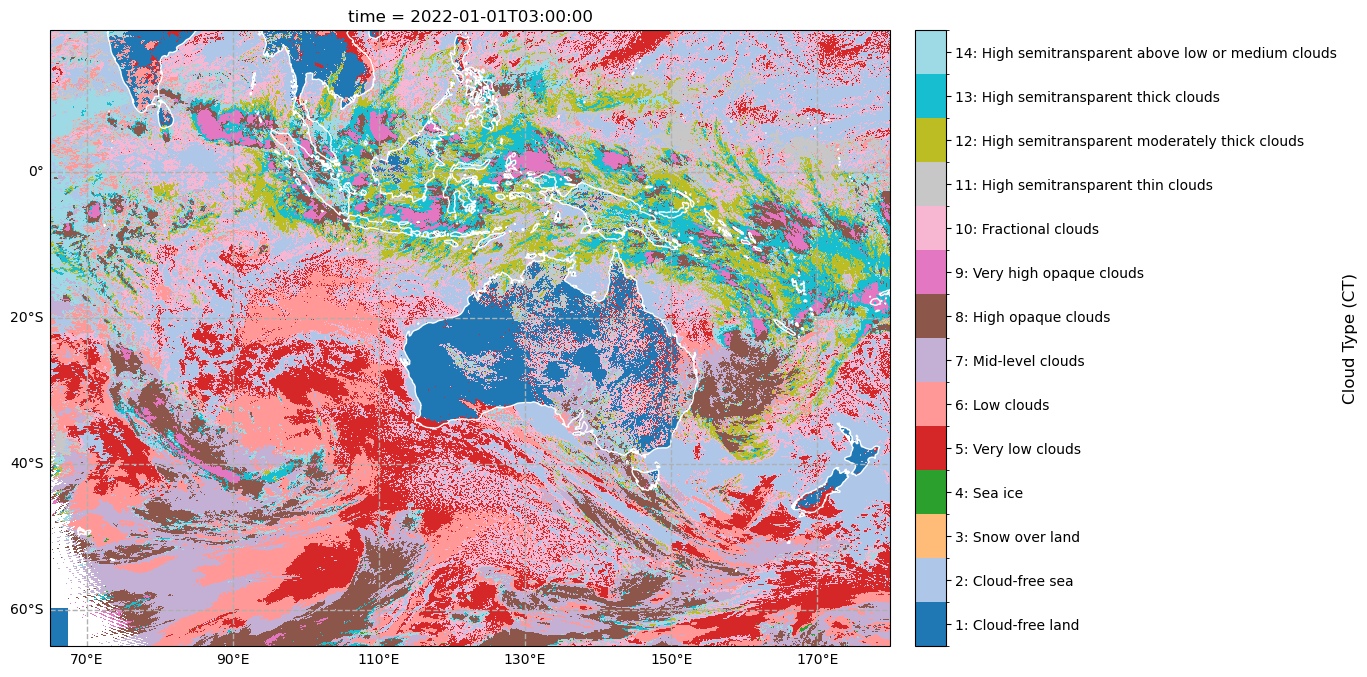

In [7]:
fig = plt.figure(figsize=(16, 8))

ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=130))
ax.coastlines(resolution="50m", color='white')

# Define the values and corresponding colors from tab20
values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]  # Adjust based on your dataset
# Set the min and max colors from tab20
min_color = mpl.colormaps['tab20'](0 / 20)
max_color = mpl.colormaps['tab20'](19 / 20)  # Last color of tab20

# Generate intermediate colors by linearly spacing them within tab20
num_classes = len(values)
colors = [mpl.colormaps['tab20'](i / (num_classes - 1)) for i in range(num_classes)]

# Ensure min/max colors are set explicitly
colors[0] = min_color
colors[-1] = max_color

# Create discrete colormap
cmap = mcolors.ListedColormap(colors)
# Define boundaries for normalization (each value gets its own bin)
boundaries = np.arange(min(values) - 0.5, max(values) + 1.5, 1)  # Adjusted for correct binning
norm = mcolors.BoundaryNorm(boundaries, cmap.N)

img = ds_z.sel(time='2022-01-01T03:00:00.000000000').ct.plot(ax=ax, x="lon", y="lat", transform=ccrs.PlateCarree(), cmap=cmap, norm=norm, add_colorbar=False)

# Add a discrete colorbar
cbar = fig.colorbar(img, ax=ax, orientation="vertical", fraction=0.03, pad=0.02)
cbar.set_label("Cloud Type (CT)", fontsize=12)
cbar.set_ticks(values)  # Ensure ticks match category values
cbar.set_ticklabels([f"{k}: {v}" for k, v in sorted(category_dict.items())[:14]])  # Custom labels

# Add gridlines with labels
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=1.0)
gl.top_labels = False  # Disable top labels
gl.right_labels = False  # Disable right labels

# Increase the number of ticks on the x-axis
gl.xlocator = mticker.FixedLocator(np.arange(70, 190, 20))  # Adjust step size as needed

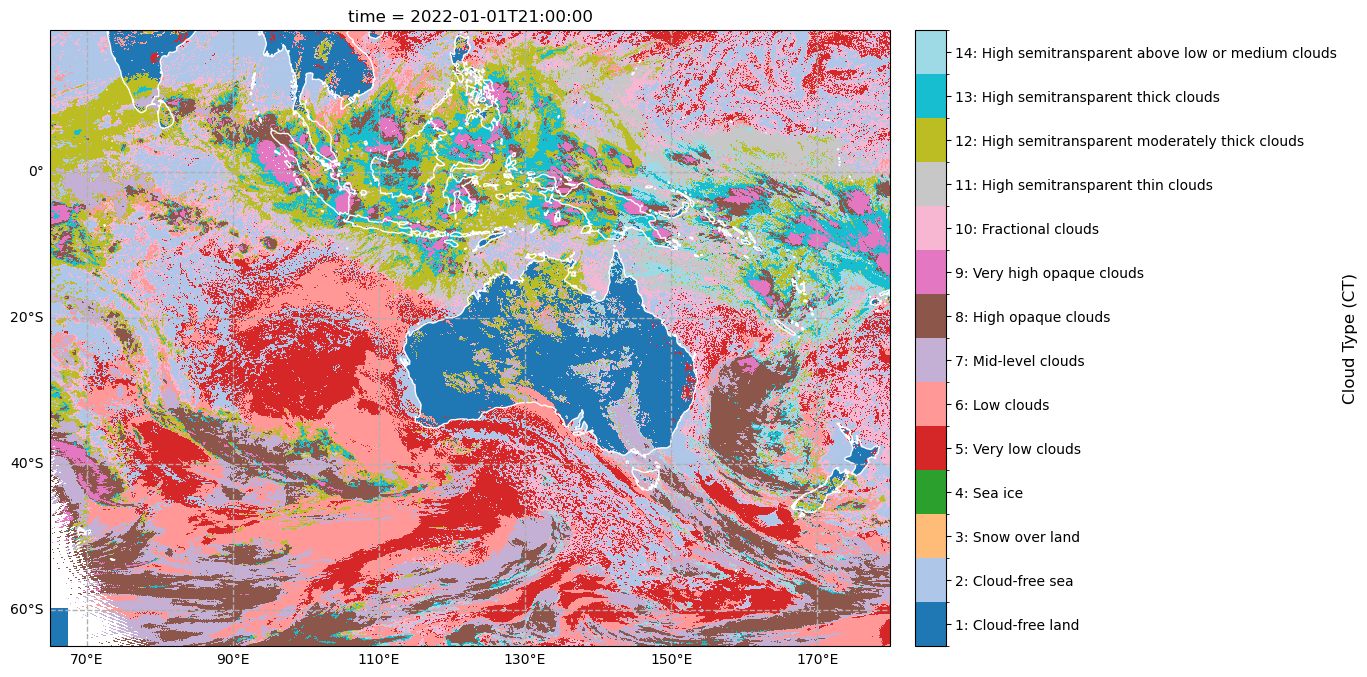

In [10]:
fig = plt.figure(figsize=(16, 8))

ax = plt.axes(projection=ccrs.PlateCarree(central_longitude=130))
ax.coastlines(resolution="50m", color='white')

# Define the values and corresponding colors from tab20
values = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]  # Adjust based on your dataset
# Set the min and max colors from tab20
min_color = mpl.colormaps['tab20'](0 / 20)
max_color = mpl.colormaps['tab20'](19 / 20)  # Last color of tab20

# Generate intermediate colors by linearly spacing them within tab20
num_classes = len(values)
colors = [mpl.colormaps['tab20'](i / (num_classes - 1)) for i in range(num_classes)]

# Ensure min/max colors are set explicitly
colors[0] = min_color
colors[-1] = max_color

# Create discrete colormap
cmap = mcolors.ListedColormap(colors)
# Define boundaries for normalization (each value gets its own bin)
boundaries = np.arange(min(values) - 0.5, max(values) + 1.5, 1)  # Adjusted for correct binning
norm = mcolors.BoundaryNorm(boundaries, cmap.N)

img = ds_z.sel(time='2022-01-01T021:00:00.000000000').ct.plot(ax=ax, x="lon", y="lat", transform=ccrs.PlateCarree(), cmap=cmap, norm=norm, add_colorbar=False)

# Add a discrete colorbar
cbar = fig.colorbar(img, ax=ax, orientation="vertical", fraction=0.03, pad=0.02)
cbar.set_label("Cloud Type (CT)", fontsize=12)
cbar.set_ticks(values)  # Ensure ticks match category values
cbar.set_ticklabels([f"{k}: {v}" for k, v in sorted(category_dict.items())[:14]])  # Custom labels

# Add gridlines with labels
gl = ax.gridlines(draw_labels=True, linestyle="--", linewidth=1.0)
gl.top_labels = False  # Disable top labels
gl.right_labels = False  # Disable right labels

# Increase the number of ticks on the x-axis
gl.xlocator = mticker.FixedLocator(np.arange(70, 190, 20))  # Adjust step size as needed